# Retail Sales Performance & Profitability Analysis

## Business Problem

Retail companies need to understand sales performance and profitability across products, regions, and customer segments.

This analysis helps identify:
- High performing products
- Loss making products
- Impact of discounts on profitability
- Regional sales performance

## Objective
The objective of this project is to analyze retail sales data to identify trends in revenue, profit, and product performance.

## Business Questions
- Which product categories generate the highest sales?
- Which regions are most profitable?
- Which products have high sales but low profit?
- What are the monthly sales trends?

## Tools Used
- Python
- Pandas
- Matplotlib / Seaborn
- SQL (optional)
- Power BI (for dashboard)

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = pd.read_csv(r"retail_sales_data.xls")

In [3]:
df.head()

,Order_ID,Order_Date,Region,State,Category,Product_Name,Customer_Segment,Sales,Quantity,Discount,Profit
0,100001,2021-03-29,East,West Bengal,Office Supplies,Pen,Consumer,45732,5,0.05,3202.94
1,100002,2023-08-14,West,Rajasthan,Furniture,Chair,Consumer,1769,8,0.15,367.36
2,100003,2022-04-21,North,Punjab,Furniture,Chair,Home Office,28480,1,0.10,4180.60
3,100004,2023-03-30,South,Tamil Nadu,Office Supplies,Paper,Home Office,2899,7,0.15,393.38
4,100005,2021-12-12,North,Delhi,Office Supplies,Paper,Consumer,11627,9,0.15,1273.54


## Dataset Overview 

Column Name        Description

- Order_ID :- |         Unique order identifier
- Order_Date :-|        Date of purchase
- Region :- |          Sales region
- State  :- |           State where order was placed
- Category :- |          Product category
- Product_Name :- |     Product name
- Customer_Segment :- |  Type of customer
- Sales :- |            Revenue generated
- Quantity :- |         Units sold
- Discount :- |        Discount applied
- Profit :- |           Profit earned

## Dataset Overview

The dataset contains retail sales transactions including
product details, customer segments, sales, and profit.

In [4]:
df.shape


(5020, 11)

In [5]:
df.columns

Index(['Order_ID', 'Order_Date', 'Region', 'State', 'Category', 'Product_Name',
       'Customer_Segment', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          5020 non-null   int64  
 1   Order_Date        5020 non-null   object 
 2   Region            5020 non-null   object 
 3   State             5020 non-null   object 
 4   Category          4989 non-null   object 
 5   Product_Name      5020 non-null   object 
 6   Customer_Segment  5020 non-null   object 
 7   Sales             5020 non-null   int64  
 8   Quantity          5020 non-null   int64  
 9   Discount          5020 non-null   float64
 10  Profit            4970 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 431.5+ KB


In [7]:
df.describe()

,Order_ID,Sales,Quantity,Discount,Profit
count,5020.000000,5020.000000,5020.000000,5020.000000,4970.000000
mean,102498.324104,25009.749602,4.989044,0.133865,2355.851360
std,1443.131286,14099.421608,2.565981,0.097777,2430.076009
min,100001.000000,1002.000000,1.000000,0.000000,-5626.480000
25%,101247.750000,12707.000000,3.000000,0.050000,541.000000
50%,102497.500000,24442.500000,5.000000,0.150000,1795.380000
75%,103748.250000,37101.500000,7.000000,0.200000,3703.045000
max,105000.000000,49993.000000,9.000000,0.300000,12385.010000


## Data Cleaning

Steps performed:
- Checked for missing values
- Removed duplicates
- Converted date columns

In [8]:
# Checking Null
df.isnull().sum()

Order_ID             0
Order_Date           0
Region               0
State                0
Category            31
Product_Name         0
Customer_Segment     0
Sales                0
Quantity             0
Discount             0
Profit              50
dtype: int64

In [9]:
df['Category'] = df['Category'].fillna(df['Category'].mode()[0])
df['Profit'] = df['Profit'].fillna(df['Profit'].median())

In [11]:
# Checking Duplicate
df[df.duplicated()].shape   # Duplicate Rows

(20, 11)

In [12]:
# Remove Duplicate

df.drop_duplicates(inplace=True)

In [13]:
# Convert Date Column

df['Order_Date']=pd.to_datetime(df['Order_Date'])

## Feature Engineering

Created new columns:
- Year
- Month
- Profit Margin

In [14]:
# Create new columns

df['Year']=df['Order_Date'].dt.year
df['Month']=df['Order_Date'].dt.month
df['Month_Name']=df['Order_Date'].dt.month_name()

In [15]:
df['Profit_Margin']=(df['Profit'] / df['Sales']) * 100

## Key Business Metrics (KPIs)

In [16]:
Total_sales = df['Sales'].sum()
Total_profit = df['Profit'].sum()
Avg_margin = df['Profit_Margin'].mean()

print('Total Sales :',Total_sales)
print('Total Profit :',Total_profit)
print('Average Margin :',Avg_margin)

Total Sales : 125042738
Total Profit : 11736248.719999999
Average Margin : 9.469950614265356


## Exploratory Data Analysis (EDA)

In [17]:
# Total Sales & Profit

print("Total Sales :",df['Sales'].sum())
print("Total Profit :",df['Profit'].sum())

Total Sales : 125042738
Total Profit : 11736248.719999999


### Sales By Category

In [18]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

Category
Office Supplies    44057446
Furniture          41941754
Technology         39043538
Name: Sales, dtype: int64

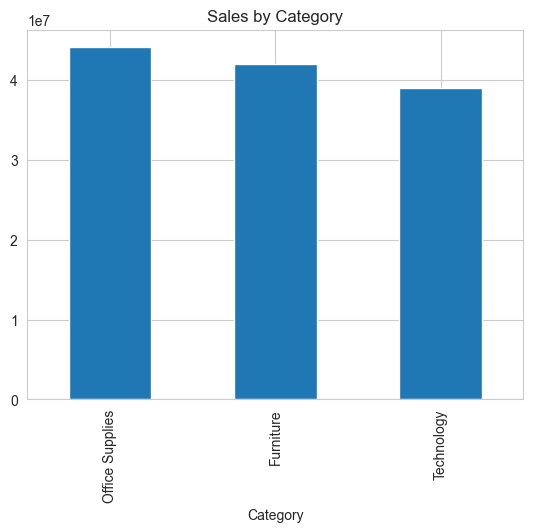

In [19]:
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

### Profit by Region

In [20]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()
region_profit

Region
North    2814701.60
South    2939230.05
East     2981139.31
West     3001177.76
Name: Profit, dtype: float64

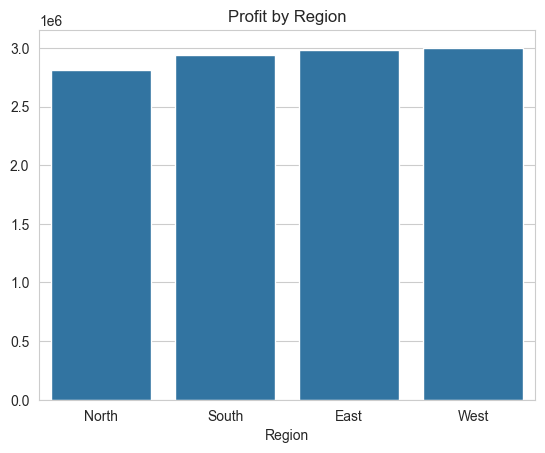

In [21]:
sns.barplot(x=region_profit.index,y=region_profit.values)
plt.title("Profit by Region")
plt.show()

### Sales by Customer Segment

In [22]:

segment_sales = df.groupby('Customer_Segment')['Sales'].sum().sort_values()
segment_sales

Customer_Segment
Home Office    40805611
Consumer       41395618
Corporate      42841509
Name: Sales, dtype: int64

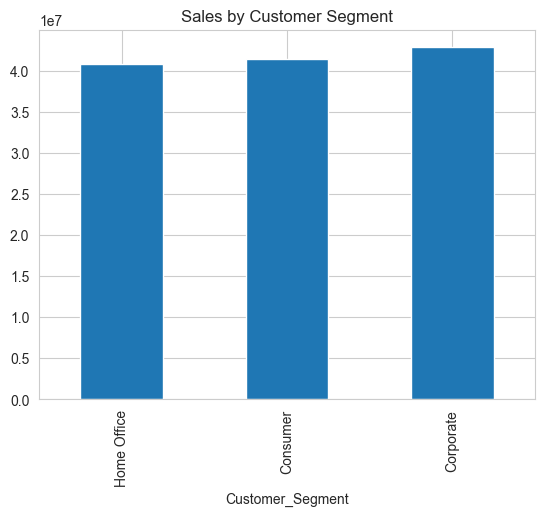

In [23]:
segment_sales.plot(kind='bar')
plt.title("Sales by Customer Segment")
plt.show()

In [24]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

df["Month_Name"] = pd.Categorical(df["Month_Name"], categories=month_order, ordered=True)

### Monthly Sales Trend

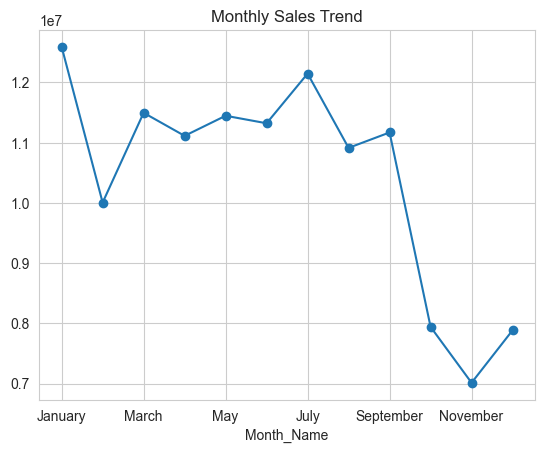

In [45]:
monthly_sales = df.groupby("Month_Name")["Sales"].sum()

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.show()


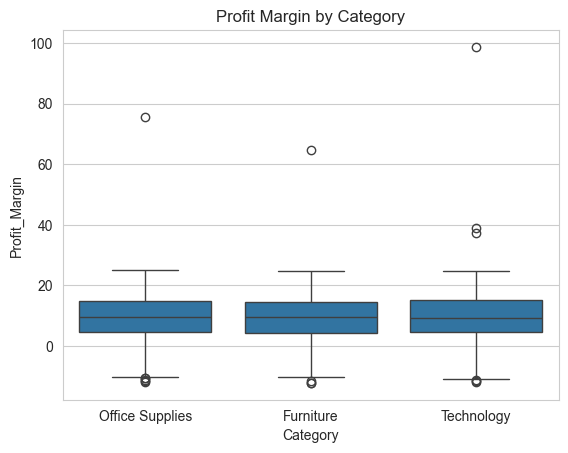

In [26]:
sns.boxplot(x="Category", y="Profit_Margin", data=df)
plt.title("Profit Margin by Category")
plt.show()

### Discount vs Profit

<Axes: xlabel='Discount', ylabel='Profit'>

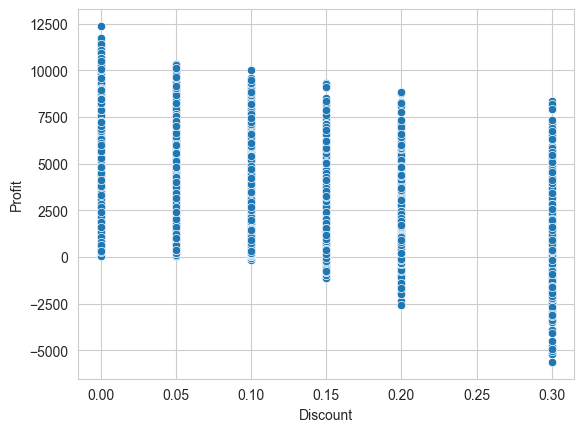

In [27]:
# Discount vs Profit
sns.scatterplot(x='Discount',y='Profit',data=df)

### Top 10 Products by Sales

In [28]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

Product_Name
Paper       11394356
Sofa        11142515
Binder      11127955
Table       10767190
Pen         10711887
Printer     10657764
Cupboard    10526354
Notebook    10223843
Phone        9848120
Laptop       9707668
Name: Sales, dtype: int64

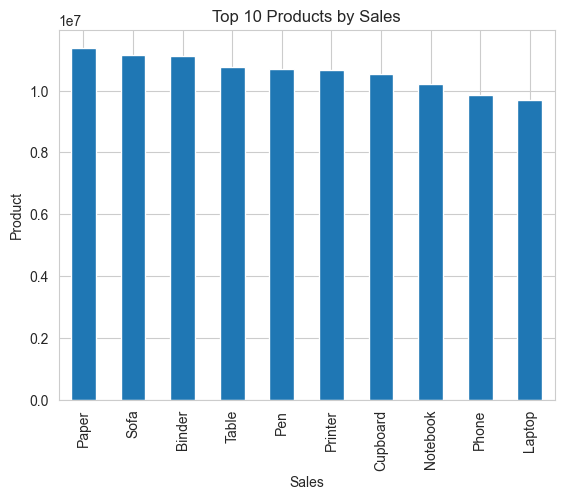

In [29]:
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

### Loss Making Products


In [30]:

loss_products = df[df['Profit'] < 0]
loss_products[['Product_Name','Sales','Profit']].head(100)

,Product_Name,Sales,Profit
28,Paper,7893,-303.30
40,Table,21056,-219.03
46,Laptop,47247,-1216.70
61,Sofa,18640,-1316.00
73,Paper,44088,-1530.40
...,...,...,...
1072,Sofa,9060,-940.03
1084,Tablet,5274,-257.44
1095,Table,31048,-286.59
1096,Notebook,6988,-427.20


### Correlation Analysis


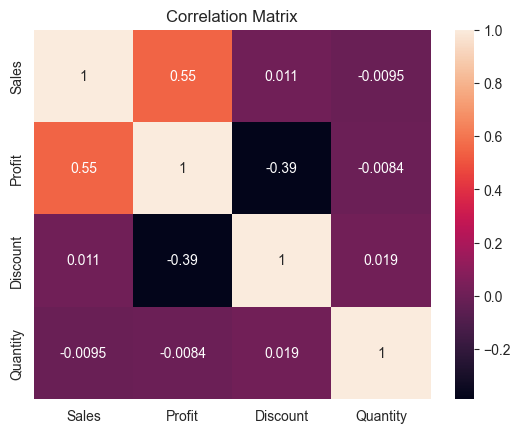

In [31]:
sns.heatmap(df[['Sales','Profit','Discount','Quantity']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## Key Insights 

1. Office Supplies category generates the highest sales.
2. West region contributes the most profit.
3. High discounts often lead to lower profits.
4. Some products generate high sales but negative profit.
5. Sales increase during certain months indicating seasonal demand.


## Recommendations

• Reduce excessive discounts on low-margin products  
• Focus marketing on high-profit categories  
• Improve pricing strategy for loss-making products  
• Increase stock for high demand products

In [46]:
df.to_excel("cleaned_retail_sales.xlsx")

In [47]:
df

,Order_ID,Order_Date,Region,State,Category,Product_Name,Customer_Segment,Sales,Quantity,Discount,Profit,Year,Month,Month_Name,Profit_Margin
0,100001,2021-03-29,East,West Bengal,Office Supplies,Pen,Consumer,45732,5,0.05,3202.94,2021,3,March,7.003717
1,100002,2023-08-14,West,Rajasthan,Furniture,Chair,Consumer,1769,8,0.15,367.36,2023,8,August,20.766535
2,100003,2022-04-21,North,Punjab,Furniture,Chair,Home Office,28480,1,0.10,4180.60,2022,4,April,14.679073
3,100004,2023-03-30,South,Tamil Nadu,Office Supplies,Paper,Home Office,2899,7,0.15,393.38,2023,3,March,13.569507
4,100005,2021-12-12,North,Delhi,Office Supplies,Paper,Consumer,11627,9,0.15,1273.54,2021,12,December,10.953298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,104996,2022-11-13,South,Karnataka,Furniture,Chair,Home Office,29017,5,0.20,1734.11,2022,11,November,5.976186
4996,104997,2021-09-19,East,West Bengal,Office Supplies,Binder,Corporate,9162,8,0.20,911.29,2021,9,September,9.946409
4997,104998,2021-02-25,South,Karnataka,Technology,Laptop,Home Office,28789,4,0.10,2663.72,2021,2,February,9.252562
4998,104999,2021-12-16,North,Delhi,Office Supplies,Notebook,Home Office,25548,4,0.15,1542.75,2021,12,December,6.038633
